In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle, SpectrumFitRow
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit
import os
import itertools
from concurrent.futures import ProcessPoolExecutor
import logging
from matplotlib.patches import Rectangle

from copy import deepcopy
from glob import glob

In [2]:
spice_cube = read_spice_l2_fits("../src/solo_L2_spice-n-ras_20220307T030536_V22_100663723-000.fits")

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-04 11:59:13 - astropy - WARNING: FITSFixedWarning: CROTA = -0.564311680665 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59645.128890 from DATE-OBS.
Set MJD-BEG to 59645.128890 from DATE-BEG.
Set MJD-AVG to 59645.136483 from DATE-AVG.
Set MJD-END to 59645.144072 from DATE-END'. [astropy.wcs.wcs]
2025-03-04 11:59:13 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59645.128890 from DATEREF.
Set MJD-OBS to 59645.128890 from DATE-OBS.
Set MJD-BEG to 59645.128890 from DATE-BEG.
Set MJD-AVG to 59645.136483 from DATE-AVG.
Set MJD-END to 59645.144072 from DATE-END'.


In [20]:
with fits.open("../src/solo_L2_spice-n-ras_20220307T030536_V22_100663723-000.fits") as hdul:
    spice_CIII_hdr = hdul[5].header.copy()
plot_aspect = spice_CIII_hdr['CDELT2']/spice_CIII_hdr['CDELT1']

In [36]:
CIII_977_data = spice_cube['C III 977 (Merged)'].data.copy()[0,:,:,:]
CIII_977_wvl = spice_cube['C III 977 (Merged)'].spectral_axis.to_value(u.AA)

In [31]:
CIII_977_data_bg_rm = CIII_977_data - np.nanmin(CIII_977_data, axis=2)[:,:,np.newaxis]

/scratch/tmp.25099103.zhuyin/ipykernel_671795/1737528971.py:1: RuntimeWarning: All-NaN slice encountered
  CIII_977_data_bg_rm = CIII_977_data - np.nanmin(CIII_977_data, axis=2)[:,:,np.newaxis]


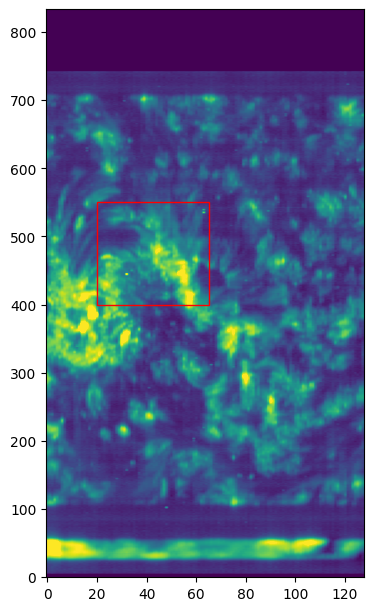

In [30]:
fig, ax = plt.subplots(figsize=(4,6), layout="constrained")
ax.imshow(np.nansum(CIII_977_data_bg_rm, axis=0), origin="lower", aspect=plot_aspect,
            norm=ImageNormalize(vmin=np.nanpercentile(np.nansum(CIII_977_data_bg_rm, axis=0), 0.5),
            vmax=np.nanpercentile(np.nansum(CIII_977_data_bg_rm, axis=0), 99.5),
            stretch=AsinhStretch()))

rect_box = Rectangle((20, 400), 45, 150, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect_box)

In [34]:
rebin_facs = [1,1,1]
CIII_data_crop = CIII_977_data_bg_rm[:,400:550,20:65]
CIII_977_data_rebin = bindown(CIII_data_crop, np.round(np.array(CIII_data_crop.shape)/rebin_facs).astype(np.int32))
CIII_977_data_transpose = CIII_977_data_rebin.transpose([2,1,0])

/scratch/tmp.25099103.zhuyin/ipykernel_671795/639287912.py:2: RuntimeWarning: Mean of empty slice
  ax.step(CIII_977_wvl, np.nanmean(CIII_977_data_rebin, axis=(1,2)), where="mid")


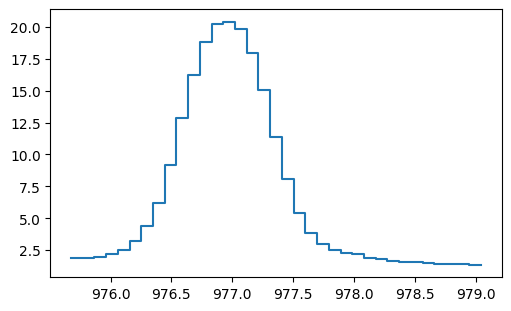

In [42]:
fig, ax = plt.subplots(figsize=(5,3), layout="constrained")
ax.step(CIII_977_wvl, np.nanmean(CIII_977_data_rebin, axis=(1,2)), where="mid")

In [43]:
def func_CIII_sg(x, wvl_977, int_977, wid_977, a, b):
    return gaussian(x, wvl_977, int_977, wid_977) + \
           a*x + b

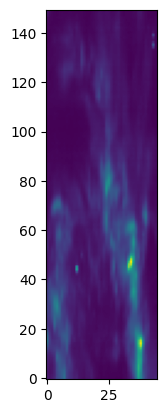

In [46]:
plt.imshow(np.nanmean(CIII_977_data_rebin, axis=0), origin="lower")

In [64]:
CIII_orig_fit_int = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_orig_fit_wvl = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_orig_fit_wid = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_orig_fit_a = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_orig_fit_b = np.zeros(CIII_977_data_rebin.shape[1:])

for ii in range(CIII_977_data_rebin.shape[1]):
    for jj in range(CIII_977_data_rebin.shape[2]):
        try:
            popt, pcov = curve_fit(func_CIII_sg,
                                CIII_977_wvl,
                                CIII_977_data_rebin[:, ii, jj],
                                p0=[CIII_977_wvl[np.nanargmax(CIII_977_data_rebin[:, ii, jj])],
                                np.nanmax(CIII_977_data_rebin[:, ii, jj]),
                                0.8,
                                0,0],
                                bounds=((0,0,0,-np.inf,-np.inf),
                                (np.inf, np.inf, np.inf, np.inf, np.inf)),
                                nan_policy="omit")
            
            CIII_orig_fit_wvl[ii, jj] = popt[0]
            CIII_orig_fit_int[ii, jj] = popt[1]
            CIII_orig_fit_wid[ii, jj] = popt[2]
            CIII_orig_fit_a[ii, jj] = popt[3]
            CIII_orig_fit_b[ii, jj] = popt[4]
        except:
            pass
        


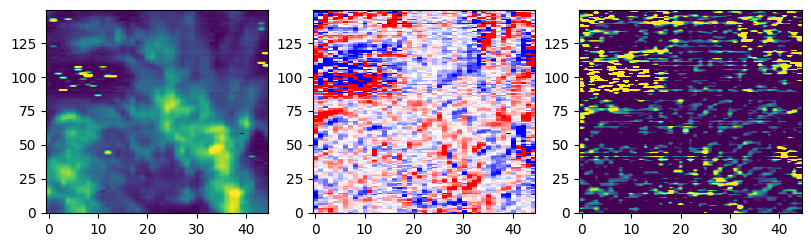

In [74]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3, figsize=(8,3), layout="constrained")

ax1.imshow(CIII_orig_fit_int, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(CIII_orig_fit_int, 0.1),
                                vmax=np.nanpercentile(CIII_orig_fit_int, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect)

ax2.imshow((CIII_orig_fit_wvl - np.nanmedian(CIII_orig_fit_wvl, axis=0)[np.newaxis,:])/977*3e5,
            norm=ImageNormalize(vmin=-30, vmax=30), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax3.imshow(CIII_orig_fit_wid, norm=ImageNormalize(vmin=0.8, vmax=0.9),
            origin="lower", aspect=plot_aspect)

In [75]:
# parameter set 1
yl_core_xpo = 1.5

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -15*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([2.0, 0.95])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([10.0, 2.5]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.2

In [76]:
spice_corr_dat, spice_corr_chi2s, metadict = correct_spice_raster(CIII_977_data_transpose, spice_CIII_hdr, fwhm_core0_yl, fwhm_wing0_yl, 
                                                                psf_yl_angle, wing_weight, yl_core_xpo=yl_core_xpo,
                                                                super_fac=1, chi2_th = 0.5,
                                                                psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
spice_corr_dat = spice_corr_dat.transpose([2,1,0])

Correcting C III 977 (Merged); ref. wavelength=975.2422520399999
Computing PSF Core:
4.984918240990633 % done after 0.7757606506347656 seconds
9.9857120177806 % done after 1.5500454902648926 seconds
14.986505794570567 % done after 2.3237478733062744 seconds
19.987299571360534 % done after 3.0961508750915527 seconds
24.9880933481505 % done after 3.8694450855255127 seconds
29.988887124940465 % done after 4.64123797416687 seconds
34.98968090173043 % done after 5.412737846374512 seconds
39.9904746785204 % done after 6.186139345169067 seconds
44.99126845531037 % done after 6.9591803550720215 seconds
49.99206223210033 % done after 7.731060266494751 seconds
54.9928560088903 % done after 8.504556655883789 seconds
59.99364978568027 % done after 9.278235912322998 seconds
64.99444356247024 % done after 10.051554679870605 seconds
69.9952373392602 % done after 11.09631872177124 seconds
74.99603111605016 % done after 11.867354154586792 seconds
79.99682489284014 % done after 12.640965461730957 second

2025-03-04 12:54:21 - numba.core.transforms - INFO: finding looplift candidates
/cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/sharpesst/util.py:83: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "_masked_medfilt_inner" failed type inference due to: Use of unsupported NumPy function 'numpy.unravel_index' or unsupported use of the function.

File "../../../sunpy_env/lib/python3.11/site-packages/sharpesst/util.py", line 86:
def _masked_medfilt_inner(flatinds,data,footprint_inds,footprint_ind_offset,tparg,dat_pad_shape,data_fppad,mask_fppad,data_filt):
    <source elided>
    for ind in flatinds:
        ijkpad = np.unravel_index(ind,data.shape)+footprint_inds-footprint_ind_offset
        ^

During: typing of get attribute at /cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/sharpesst/util.py (86)

File "../../../sunpy_env/lib/python3.11/site-packages/sharpesst/util.py", line 86:
def _masked_medfilt_inner(flati

Correcting the PSF:
2.771749973297119 s; Finished slit index 0 of 45 , chi^2= 0.7555165315012793
6.101183891296387 s; Finished slit index 1 of 45 , chi^2= 0.8095839226412997
8.28294849395752 s; Finished slit index 2 of 45 , chi^2= 0.790787609164926
10.69063949584961 s; Finished slit index 3 of 45 , chi^2= 0.794460519315309
13.205618381500244 s; Finished slit index 4 of 45 , chi^2= 0.8175362052413592
15.84582805633545 s; Finished slit index 5 of 45 , chi^2= 0.8071281611427236
18.650203227996826 s; Finished slit index 6 of 45 , chi^2= 0.7674855883715268
21.387691497802734 s; Finished slit index 7 of 45 , chi^2= 0.7039938880868111
24.394227027893066 s; Finished slit index 8 of 45 , chi^2= 0.7426129692448573
27.479588985443115 s; Finished slit index 9 of 45 , chi^2= 0.742670684737282
31.315787076950073 s; Finished slit index 10 of 45 , chi^2= 0.8242524215728955
35.49772572517395 s; Finished slit index 11 of 45 , chi^2= 0.773881042055464
40.17874574661255 s; Finished slit index 12 of 45 , c

In [77]:
CIII_corr_fit_int = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_corr_fit_wvl = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_corr_fit_wid = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_corr_fit_a = np.zeros(CIII_977_data_rebin.shape[1:])
CIII_corr_fit_b = np.zeros(CIII_977_data_rebin.shape[1:])

for ii in range(CIII_977_data_rebin.shape[1]):
    for jj in range(CIII_977_data_rebin.shape[2]):
        try:
            popt, pcov = curve_fit(func_CIII_sg,
                                CIII_977_wvl,
                                spice_corr_dat[:, ii, jj],
                                p0=[CIII_977_wvl[np.nanargmax(spice_corr_dat[:, ii, jj])],
                                np.nanmax(spice_corr_dat[:, ii, jj]),
                                0.8,
                                0,0],
                                bounds=((0,0,0,-np.inf,-np.inf),
                                (np.inf, np.inf, np.inf, np.inf, np.inf)),
                                nan_policy="omit")
            
            CIII_corr_fit_wvl[ii, jj] = popt[0]
            CIII_corr_fit_int[ii, jj] = popt[1]
            CIII_corr_fit_wid[ii, jj] = popt[2]
            CIII_corr_fit_a[ii, jj] = popt[3]
            CIII_corr_fit_b[ii, jj] = popt[4]
        except:
            pass

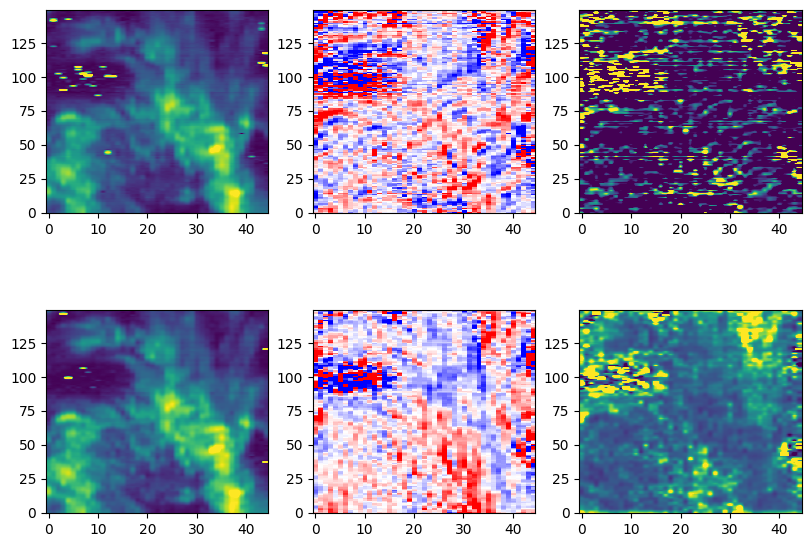

In [85]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3, figsize=(8,6), layout="constrained")

ax1.imshow(CIII_orig_fit_int, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(CIII_orig_fit_int, 0.1),
                                vmax=np.nanpercentile(CIII_orig_fit_int, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect)

ax2.imshow((CIII_orig_fit_wvl - np.nanmedian(CIII_orig_fit_wvl, axis=0)[np.newaxis,:])/977*3e5,
            norm=ImageNormalize(vmin=-30, vmax=30), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax3.imshow(CIII_orig_fit_wid, norm=ImageNormalize(vmin=0.8, vmax=0.9),
            origin="lower", aspect=plot_aspect)

ax4.imshow(CIII_corr_fit_int, origin="lower",
            norm=ImageNormalize(vmin=np.nanpercentile(CIII_corr_fit_int, 0.1),
                                vmax=np.nanpercentile(CIII_corr_fit_int, 99.5),
                                stretch=AsinhStretch(0.1)), aspect=plot_aspect)

ax5.imshow((CIII_corr_fit_wvl - np.nanmedian(CIII_corr_fit_wvl, axis=0)[np.newaxis,:])/977*3e5,
            norm=ImageNormalize(vmin=-30, vmax=30), cmap="bwr", origin="lower",
            aspect=plot_aspect, interpolation='none')

ax6.imshow(CIII_corr_fit_wid, norm=ImageNormalize(vmin=0.3, vmax=0.5),
            origin="lower", aspect=plot_aspect)

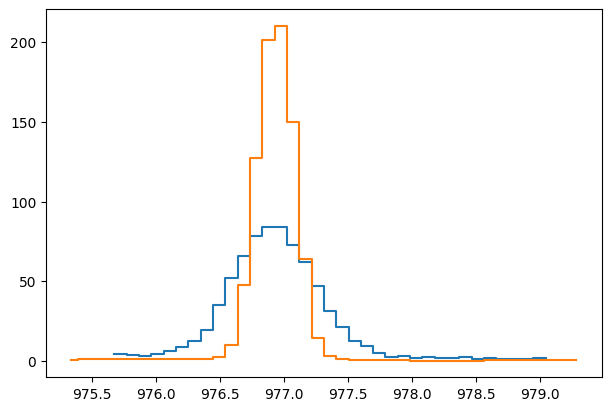

In [81]:
select_index = 70, 5
fig, ax = plt.subplots(figsize=(6,4), layout="constrained")
ax.step(CIII_977_wvl, CIII_977_data_rebin[:,*select_index], where="mid")
ax.step(CIII_977_wvl, spice_corr_dat[:,*select_index], where="mid")

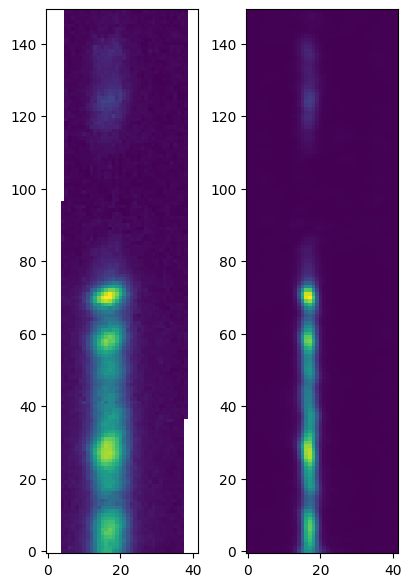

In [84]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(4,6), layout="constrained")
ax1.imshow(CIII_977_data_rebin[:,:,5].T, origin="lower")
ax2.imshow(spice_corr_dat[:,:,5].T, origin="lower")